<a href="https://colab.research.google.com/github/javidfarsoft-bot/brain-tumor-detection-comparison/blob/main/01_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Dataset Preparation

*   List item
*   List item



Download, merge, verify, and explore the MRI Brain Tumor with Bounding Boxes dataset.

In [ ]:
!git clone https://github.com/javidfarsoft-bot/brain-tumor-detection-comparison.git
%cd brain-tumor-detection-comparison
!pip install kaggle -q

Cloning into 'brain-tumor-detection-comparison'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 156 (delta 61), reused 129 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 17.28 MiB | 25.34 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/brain-tumor-detection-comparison


In [ ]:
!mkdir -p ~/.kaggle
!echo YOUR_KAGGLE_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!kaggle datasets download -d ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
!mkdir -p data/raw
!unzip -q -o mri-for-brain-tumor-with-bounding-boxes.zip -d data/raw

Dataset URL: https://www.kaggle.com/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes
License(s): CC0-1.0
100% 133M/133M [00:07<00:00, 18.3MB/s]



In [ ]:
!python -m src.data.merge_dataset --src data/raw --dst data/yolo

Total images found: 5247
Train: 4197  Valid: 522  Test: 528
Done.


In [ ]:
import os

issues = {"missing_label": [], "empty_label": [], "invalid_bbox": [], "out_of_range": []}

for split in ["train", "valid", "test"]:
    img_dir = f"data/yolo/{split}/images"
    lbl_dir = f"data/yolo/{split}/labels"
    for img_name in os.listdir(img_dir):
        lbl_name = img_name.rsplit(".", 1)[0] + ".txt"
        lbl_path = os.path.join(lbl_dir, lbl_name)
        if not os.path.exists(lbl_path):
            issues["missing_label"].append(f"{split}/{img_name}")
            continue
        lines = open(lbl_path).read().strip().splitlines()
        if not lines:
            issues["empty_label"].append(f"{split}/{img_name}")
            continue
        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                issues["invalid_bbox"].append(f"{split}/{img_name}: {line}")
                continue
            cls, xc, yc, w, h = map(float, parts)
            if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < w <= 1 and 0 < h <= 1):
                issues["out_of_range"].append(f"{split}/{img_name}: {line}")

for k, v in issues.items():
    print(f"{k}: {len(v)}")

missing_label: 0
empty_label: 1
invalid_bbox: 0
out_of_range: 0


Result: 0 missing labels, 1 empty label (`train/gg (342).jpg`), 0 malformed lines, 0 out-of-range coordinates. The single empty-label image was removed (final total: 5,246 images).

In [ ]:
import os

img_path = "data/yolo/train/images/gg (342).jpg"
lbl_path = "data/yolo/train/labels/gg (342).txt"
if os.path.exists(img_path):
    os.remove(img_path)
    os.remove(lbl_path)
print("Train count:", len(os.listdir("data/yolo/train/images")))

Train count: 4196


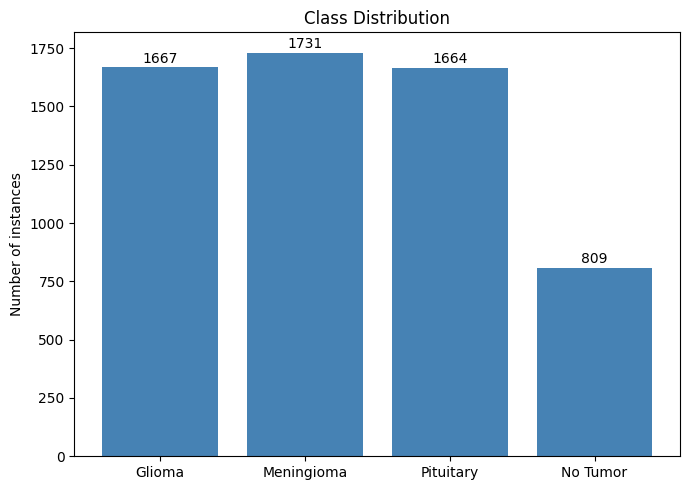

{'Glioma': 1667, 'Meningioma': 1731, 'Pituitary': 1664, 'No Tumor': 809}


In [ ]:
import matplotlib.pyplot as plt

class_names = ["Glioma", "Meningioma", "Pituitary", "No Tumor"]
counts = {}
for split in ["train", "valid", "test"]:
    lbl_dir = f"data/yolo/{split}/labels"
    for f in os.listdir(lbl_dir):
        with open(f"{lbl_dir}/{f}") as file:
            for line in file:
                cls = int(line.split()[0])
                name = class_names[cls]
                counts[name] = counts.get(name, 0) + 1

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(counts.keys(), counts.values(), color="steelblue")
ax.set_ylabel("Number of instances")
ax.set_title("Class Distribution")
for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/class_distribution.png", dpi=150)
plt.show()
print(counts)

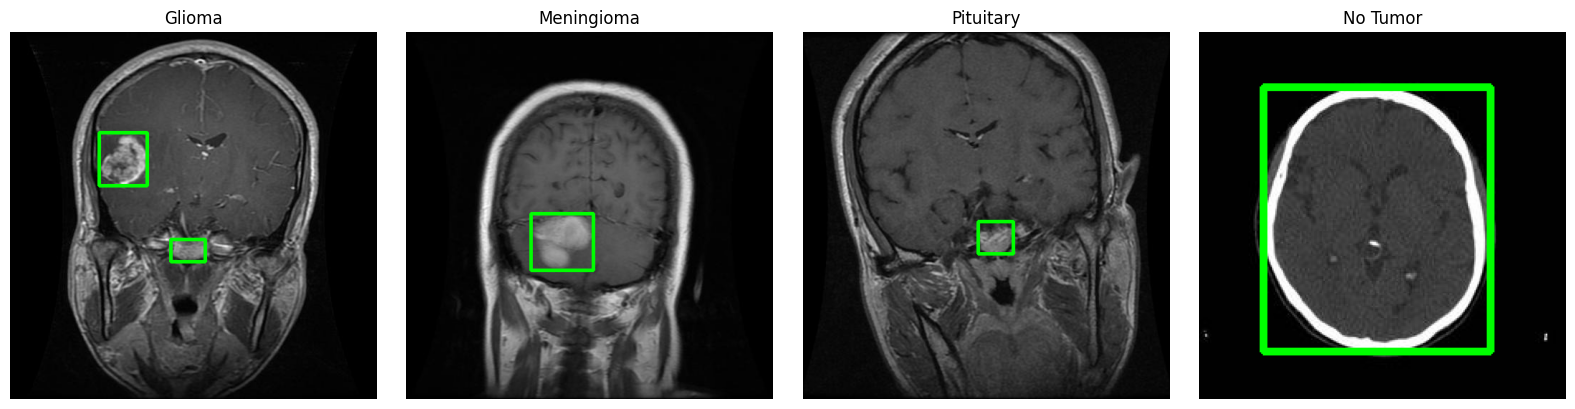

In [ ]:
import cv2, random

img_dir = "data/yolo/train/images"
lbl_dir = "data/yolo/train/labels"

class_files = {name: [] for name in class_names}
for lbl_file in os.listdir(lbl_dir):
    with open(f"{lbl_dir}/{lbl_file}") as f:
        line = f.readline()
        if line:
            cls_id = int(line.split()[0])
            class_files[class_names[cls_id]].append(lbl_file)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, cname in enumerate(class_names):
    lbl_file = random.choice(class_files[cname])
    img_name = lbl_file.replace(".txt", ".jpg")
    img = cv2.imread(f"{img_dir}/{img_name}")
    h, w = img.shape[:2]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with open(f"{lbl_dir}/{lbl_file}") as f:
        for line in f:
            c, xc, yc, bw, bh = map(float, line.split())
            x1, y1 = int((xc-bw/2)*w), int((yc-bh/2)*h)
            x2, y2 = int((xc+bw/2)*w), int((yc+bh/2)*h)
            cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
    axes[i].imshow(img)
    axes[i].set_title(cname)
    axes[i].axis("off")
plt.tight_layout()
plt.savefig("results/figures/sample_grid.png", dpi=150)
plt.show()

## Verification checklist (per project brief)

- [x] Image count verified: 5,247 downloaded, 5,246 after removing 1 corrupt sample
- [x] Annotations present and parse correctly (YOLO format)
- [x] Number of classes verified — **dataset ships 4 classes, brief specifies 5** (documented discrepancy, not a preparation error)
- [x] Train/validation/test split verified: 4,196 / 522 / 528, stratified per class, seed=42
- [x] Annotation quality checked (see results above)
- [x] Annotations converted to COCO format where needed (see notebook 02, for Faster R-CNN)